In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


duration_group
<1s          2
1-2s         2
2-3s         1
3-5s         4
5-7s         0
7-8s         0
8-9s         2
9-10s        0
10-15s       7
15-20s       1
20-30s      14
30-40s       4
40-50s       2
50-60s       8
1-1.5min     7
1.5-2min     4
2-3min       7
3-5min      14
5-10min      7
10-15min     3
15min+       3
Name: count, dtype: int64


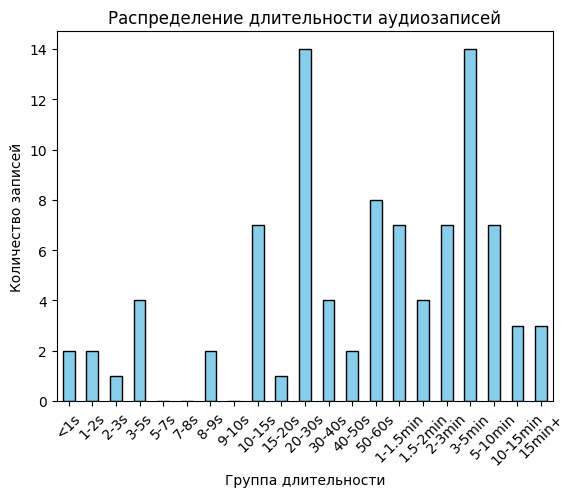

Аудиозаписей до: 92
Аудиозаписей после: 70


In [5]:
# Загрузка данных
# df = pd.read_csv("/home/user/papkamusik/action_folder/features_1000.csv")
df = pd.read_csv("/home/user/papkamusik/action_folder/google_folder/result_168.csv")

# Определяем бины и метки (количество меток = количество бинов - 1)

bins = [
    0, 1, 2, 3, 5, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60,
    90, 120, 180, 300, 600, 900, float('inf')
]
labels = [
    "<1s", "1-2s", "2-3s", "3-5s", "5-7s", "7-8s", "8-9s","9-10s", "10-15s", "15-20s",
    "20-30s", "30-40s", "40-50s", "50-60s",
    "1-1.5min", "1.5-2min", "2-3min", "3-5min", "5-10min", "10-15min", "15min+"
]

# Создаём группу длительности
df = df[df['role']=='user']
df["duration_group"] = pd.cut(df["total_duration"], bins=bins, labels=labels, right=False)

# Подсчёт количества записей в каждой группе
counts = df["duration_group"].value_counts().sort_index()
print(counts)

counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Распределение длительности аудиозаписей")
plt.xlabel("Группа длительности")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)
plt.show()

# от 20 секунд аудио берем!
# до 5 минут аудио берем!

df_result = df[(df["total_duration"] < 300) & (df["total_duration"] > 5)]
print(f"Аудиозаписей до: {len(df)}")
print(f"Аудиозаписей после: {len(df_result)}")

df_result.to_csv("/home/user/papkamusik/action_folder/google_folder/filtered_168.csv", index=False)

0
age_group
1-18 y.o      51
18-25 y.o     46
25-30 y.o     70
30-40 y.o    118
40-50 y.o     71
50-60 y.o     41
60-70 y.o     32
70-80 y.o     17
80-90 y.o      3
>90            4
Name: count, dtype: int64


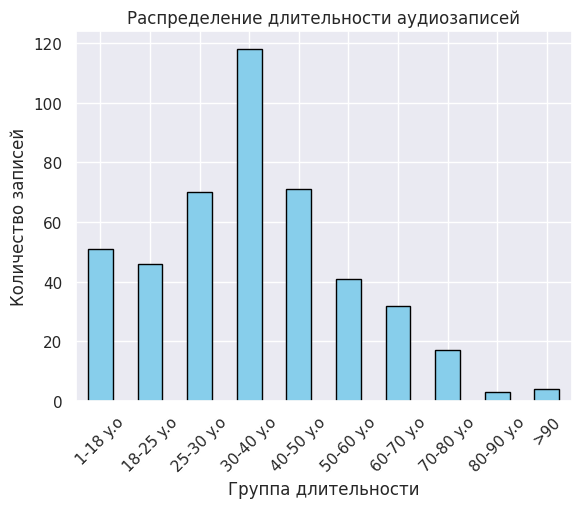

Аудиозаписей до: 453
Аудиозаписей после: 400


In [132]:
# Загрузка данных
gender_age = pd.read_csv("/home/user/papkamusik/action_folder/alone/hash_sex_age.csv")
final_df = pd.read_csv("/home/user/papkamusik/action_folder/resulted_100.csv")

final_df = final_df.merge(
    gender_age,
    left_on="call_id",
    right_on="hash",
    how="left"
)

final_df = final_df.dropna()
final_df.drop(columns=["hash"], inplace=True)

print(final_df["age"].isna().sum())

# Определяем бины и метки (количество меток = количество бинов - 1)

bins = [
    1, 18, 25, 30, 40, 50, 60, 70, 80, 90, float('inf')
]
labels = [      
    "1-18 y.o", "18-25 y.o", "25-30 y.o", "30-40 y.o", "40-50 y.o", "50-60 y.o", "60-70 y.o", "70-80 y.o", "80-90 y.o", ">90"
]

# Создаём группу длительности
final_df["age_group"] = pd.cut(final_df["age"], bins=bins, labels=labels, right=False)

# Подсчёт количества записей в каждой группе
counts = final_df["age_group"].value_counts().sort_index()
print(counts)

counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Распределение длительности аудиозаписей")
plt.xlabel("Группа длительности")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)
plt.show()

# от 18 лет и старше берем!
final_df_result = final_df[(final_df["age"] > 18)]
print(f"Аудиозаписей до: {len(final_df)}")
print(f"Аудиозаписей после: {len(final_df_result)}")


final_df_result.to_csv("filtered_resulted_100.csv")

In [2]:
final_df = pd.read_csv("/home/user/papkamusik/action_folder/filtered_resulted_100.csv")
final_df

,Unnamed: 0,call_id,role,total_duration,f0_mean,f0_median,f0_variance,f0_std,f0_min,f0_max,...,spectral_flatness_min,spectral_flatness_max,spectral_flatness_range,spectral_flatness_skew,spectral_flatness_kurtosis,spectral_flatness_cv,duration_group,sex,age,age_group
0,0,6dd09bb55ea0f2b363323075ebd80891,user,96.639,160.296460,157.185579,1675.346531,40.930997,74.967251,299.948467,...,4.532922e-07,0.023119,0.023119,8.940519,107.470968,2.684108,1.5-2min,Male,54.0,50-60 y.o
1,2,7c749f781537e584be74e1c6231bc0d7,user,48.640,200.123394,200.632542,1470.666892,38.349275,74.967567,299.945509,...,2.656452e-07,0.034895,0.034894,12.991871,220.951054,2.923322,40-50s,Female,40.0,40-50 y.o
2,3,4f331c8df6c7daf200725fee910669c7,user,66.580,201.507328,199.463008,1525.067940,39.052118,74.947810,299.798429,...,7.132432e-07,0.023383,0.023382,6.398229,56.406650,2.549637,1-1.5min,Female,50.0,50-60 y.o
3,4,be754baf8e32c3cbf0d7c704332baa8d,user,133.540,210.380713,209.920131,1666.750450,40.825855,75.061698,299.860337,...,4.355283e-07,0.029109,0.029108,10.257932,137.638885,3.127183,2-3min,Male,48.0,40-50 y.o
4,5,b2934e30184a1f8ab4ef3c336730feef,user,62.141,223.552908,223.626064,1293.551901,35.965983,77.497462,299.981354,...,4.703544e-07,0.041866,0.041866,12.842789,222.104988,2.588607,1-1.5min,Female,30.0,30-40 y.o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,540,c0f45db39d7c607598b57fbae8c8d0c6,user,54.860,141.832459,136.774154,837.387153,28.937642,75.257341,275.289250,...,1.992328e-06,0.047694,0.047692,9.240815,102.884789,3.690126,50-60s,Male,61.0,60-70 y.o
396,541,618acac51fe576c7cf7891bc2a15a4a9,user,73.519,206.384069,202.403295,1444.051724,38.000681,75.866949,299.840799,...,8.332757e-07,1.000000,0.999999,4.962287,22.649889,4.964676,1-1.5min,Male,39.0,30-40 y.o
397,542,942bcd5d9aa456ffe71e6876158ec9e2,user,54.079,182.565872,182.479290,1328.687454,36.451165,74.950293,298.334976,...,4.847070e-07,0.044532,0.044532,13.328122,261.255785,4.122211,50-60s,Female,61.0,60-70 y.o
398,543,6b3c5465fce56be39e3a61be55bd3bc0,user,36.780,227.964270,232.747192,1389.948327,37.282011,87.066962,299.924789,...,2.022659e-06,0.115210,0.115208,11.567612,144.758252,3.363312,30-40s,Male,20.0,18-25 y.o


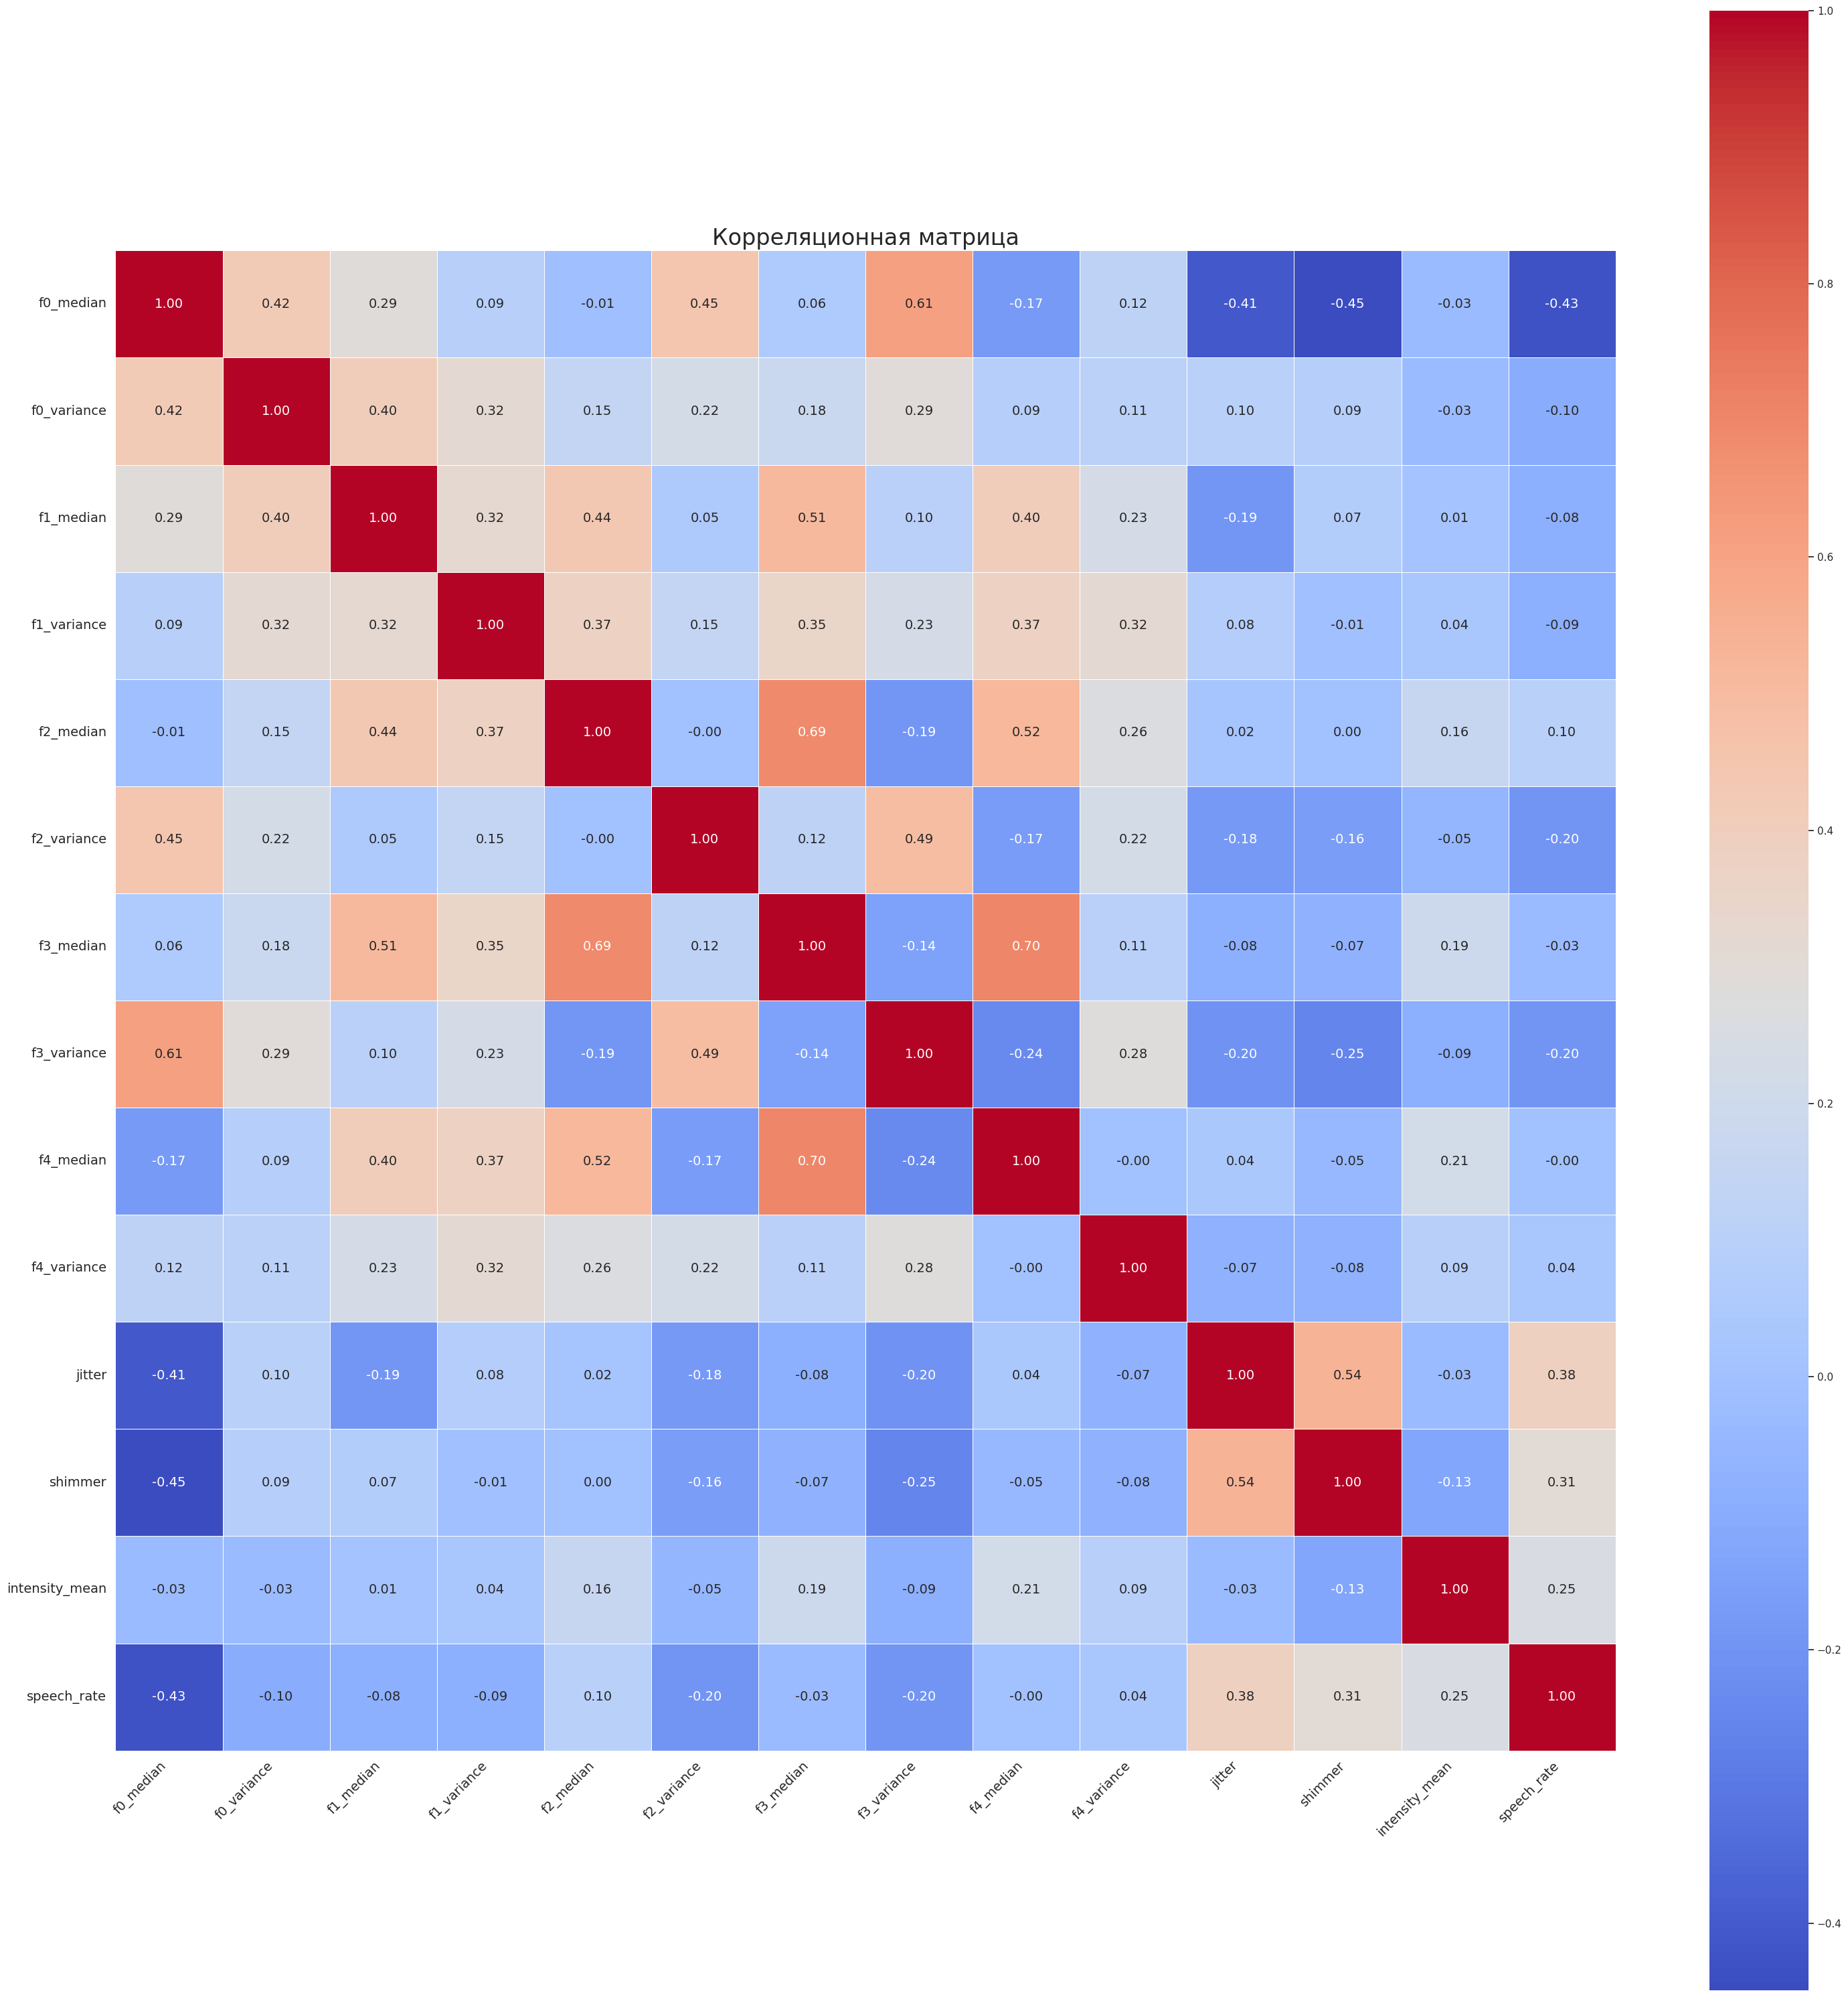

In [ ]:
final_df.drop(columns=[

    # общие
    "total_duration", "age",

    # F0
    "f0_mean", "f0_std", "f0_max", "f0_range","f0_cv","f0_skew","f0_kurtosis","f0_min",
# "f1_variance", "f1_median",
    # F1–F4
    "f1_mean", "f1_std", "f1_max","f1_min", "f1_range","f1_cv","f1_skew","f1_kurtosis", 
    "f2_mean", "f2_std", "f2_max","f2_min", "f2_range","f2_cv","f2_skew","f2_kurtosis", 
    "f3_mean", "f3_std", "f3_max","f3_min", "f3_range","f3_cv","f3_skew","f3_kurtosis",
    "f4_mean", "f4_std", "f4_max","f4_min", "f4_range","f4_cv","f4_skew","f4_kurtosis",

    # intensity / energy
    "intensity_std",
    "energy_mean", "energy_std", "energy_std", "energy_max", "energy_skew","energy_range","energy_median",

    # MFCC (1–6 базовая чистка)
    "mfcc1_mean","mfcc1_median","mfcc1_variance","mfcc1_std","mfcc1_min","mfcc1_max","mfcc1_range","mfcc1_skew","mfcc1_kurtosis","mfcc1_cv",
    "mfcc2_mean","mfcc2_median","mfcc2_variance","mfcc2_std","mfcc2_min","mfcc2_max","mfcc2_range","mfcc2_skew","mfcc2_kurtosis","mfcc2_cv",
    "mfcc3_mean","mfcc3_median","mfcc3_variance","mfcc3_std","mfcc3_min","mfcc3_max","mfcc3_range","mfcc3_skew","mfcc3_kurtosis","mfcc3_cv",
    "mfcc4_mean","mfcc4_median","mfcc4_variance","mfcc4_std","mfcc4_min","mfcc4_max","mfcc4_range","mfcc4_skew","mfcc4_kurtosis","mfcc4_cv",
    "mfcc5_mean","mfcc5_median","mfcc5_variance","mfcc5_std","mfcc5_min","mfcc5_max","mfcc5_range","mfcc5_skew","mfcc5_kurtosis","mfcc5_cv",
    "mfcc6_mean","mfcc6_median","mfcc6_variance","mfcc6_std","mfcc6_min","mfcc6_max","mfcc6_range","mfcc6_skew","mfcc6_kurtosis","mfcc6_cv",

    # MFCC 7–13 (ПОЛНОСТЬЮ УДАЛЯЕМ)
    "mfcc7_mean","mfcc7_median","mfcc7_variance","mfcc7_std","mfcc7_min","mfcc7_max","mfcc7_range","mfcc7_skew","mfcc7_kurtosis","mfcc7_cv",
    "mfcc8_mean","mfcc8_median","mfcc8_variance","mfcc8_std","mfcc8_min","mfcc8_max","mfcc8_range","mfcc8_skew","mfcc8_kurtosis","mfcc8_cv",
    "mfcc9_mean","mfcc9_median","mfcc9_variance","mfcc9_std","mfcc9_min","mfcc9_max","mfcc9_range","mfcc9_skew","mfcc9_kurtosis","mfcc9_cv",
    "mfcc10_mean","mfcc10_median","mfcc10_variance","mfcc10_std","mfcc10_min","mfcc10_max","mfcc10_range","mfcc10_skew","mfcc10_kurtosis","mfcc10_cv",
    "mfcc11_mean","mfcc11_median","mfcc11_variance","mfcc11_std","mfcc11_min","mfcc11_max","mfcc11_range","mfcc11_skew","mfcc11_kurtosis","mfcc11_cv",
    "mfcc12_mean","mfcc12_median","mfcc12_variance","mfcc12_std","mfcc12_min","mfcc12_max","mfcc12_range","mfcc12_skew","mfcc12_kurtosis","mfcc12_cv",
    "mfcc13_mean","mfcc13_median","mfcc13_variance","mfcc13_std","mfcc13_min","mfcc13_max","mfcc13_range","mfcc13_skew","mfcc13_kurtosis","mfcc13_cv",

    # spectral centroid
    "spectral_centroid_mean", "spectral_centroid_median",
    "spectral_centroid_variance", "spectral_centroid_std",
    "spectral_centroid_min", "spectral_centroid_max",
    "spectral_centroid_range", "spectral_centroid_cv",
    "spectral_centroid_skew", "spectral_centroid_kurtosis",

    # spectral bandwidth
    "spectral_bandwidth_mean", "spectral_bandwidth_median",
    "spectral_bandwidth_variance",
    "spectral_bandwidth_std",
    "spectral_bandwidth_cv",
    "spectral_bandwidth_max",
    "spectral_bandwidth_range",
    "spectral_bandwidth_kurtosis",
    "spectral_bandwidth_skew",
    "spectral_bandwidth_min",

    # spectral rolloff
    "spectral_rolloff_mean", "spectral_rolloff_median",
    "spectral_rolloff_variance", "spectral_rolloff_std",
    "spectral_rolloff_max", "spectral_rolloff_range",
    "spectral_rolloff_kurtosis", "spectral_rolloff_cv",
    "spectral_rolloff_skew","spectral_rolloff_min",

    # spectral flatness
    "spectral_flatness_mean", "spectral_flatness_median", "spectral_flatness_min",
    "spectral_flatness_variance", "spectral_flatness_std",
    "spectral_flatness_max", "spectral_flatness_range",
    "spectral_flatness_skew", "spectral_flatness_kurtosis", "spectral_flatness_cv",

    "energy_cv", "energy_min", "energy_kurtosis", "energy_variance",
    "Unnamed: 0",

    # ОСТАВЛЯЕМ ТОЛЬКО ЭТИ (их НЕ добавляем в drop!)
    # f0_median
    # jitter
    # shimmer
    # speech_rate
    # intensity_mean

], inplace=True)

final_df = final_df[final_df["role"]=="user"]

numeric = final_df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()

# -------- корреляционная матрица --------
plt.figure(figsize=(30,30))  # увеличили размер

sns.set(font_scale=1)  # увеличили шрифт
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    df = df.select_dtypes(include=["number"]).dropna()

    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]

    return vif_data.sort_values("VIF", ascending=False)

vif_df = compute_vif(final_df)
print(vif_df)

           feature          VIF
6        f3_median  1652.679940
8        f4_median  1309.763415
4        f2_median   284.770024
2        f1_median   156.526209
12  intensity_mean    99.405870
10          jitter    75.100403
11         shimmer    67.998255
0        f0_median    42.684281
13     speech_rate    38.397907
9      f4_variance    26.543138
7      f3_variance    23.844572
5      f2_variance    17.717433
1      f0_variance    10.225514
3      f1_variance     9.357885


In [ ]:
# убираем дубликаты и диагональ
upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# выбираем пары с корреляцией > 0.7
high_corr = [(col1, col2, upper.loc[col1, col2]) 
             for col1 in upper.columns 
             for col2 in upper.columns 
             if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] > 0.69]

# выводим
for col1, col2, val in high_corr:
    print(f"{col1} ↔ {col2}: {val:.2f}")

f2_median ↔ f3_median: 0.69


In [37]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import umap
import plotly.express as px


def sanity_check_5plots_grid(
    df,
    output_dir="sanity_plots",
    id_col=None,
    label_col=None
):

    os.makedirs(output_dir, exist_ok=True)

    # =========================
    # DATA
    # =========================
    X_df = df.select_dtypes(include=[np.number]).copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna()

    X = StandardScaler().fit_transform(X_df)

    labels = df[label_col].astype(str) if label_col else pd.Series(["all"] * len(df))
    ids = df[id_col].astype(str) if id_col else df.index.astype(str)

    # =========================
    # PARAM GRIDS
    # =========================
    tsne_perplexities = [5, 10, 20, 30, 40, 50]
    tsne_lr = [10, 50, 100, 200, 300]

    umap_neighbors = [5, 10, 15, 30, 50, 100]
    umap_min_dist = [0.001, 0.01, 0.1, 0.3]

    # =========================
    # PLOT HELPER
    # =========================
    def save_plot(X_2d, name, params=""):

        df_plot = pd.DataFrame({
            "x": X_2d[:, 0],
            "y": X_2d[:, 1],
            "label": labels.values,
            "id": ids.values
        })

        fig = px.scatter(
            df_plot,
            x="x",
            y="y",
            color="label",
            hover_data=["id"],
            title=f"{name} {params}"
        )

        path = os.path.join(output_dir, f"{name}.html")
        fig.write_html(path, include_plotlyjs="cdn")

        print(f"✔ saved: {path}")

    # =========================
    # 1. PCA (baseline fixed)
    # =========================
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X)
    save_plot(X_pca_2d, "PCA_2D")

    # =========================
    # 2. TSNE RAW GRID
    # =========================
    best_score = -1
    best_X = None
    best_params = None

    for p in tsne_perplexities:
        for lr in tsne_lr:

            X_red = TSNE(
                n_components=2,
                perplexity=p,
                learning_rate=lr,
                init="pca",
                random_state=42
            ).fit_transform(X)

            try:
                score = silhouette_score(X_red, labels)
            except:
                continue

            if score > best_score:
                best_score = score
                best_X = X_red
                best_params = (p, lr)

    save_plot(best_X, "TSNE_RAW", f"p={best_params[0]} lr={best_params[1]}")

    # =========================
    # 3. UMAP RAW GRID
    # =========================
    best_score = -1
    best_X = None
    best_params = None

    for n in umap_neighbors:
        for md in umap_min_dist:

            X_red = umap.UMAP(
                n_components=2,
                n_neighbors=n,
                min_dist=md,
                random_state=42
            ).fit_transform(X)

            score = silhouette_score(X_red, labels)

            if score > best_score:
                best_score = score
                best_X = X_red
                best_params = (n, md)

    save_plot(best_X, "UMAP_RAW", f"n={best_params[0]} md={best_params[1]}")

    # =========================
    # 4. PCA BEFORE
    # =========================
    X_pca = PCA(n_components=0.95, random_state=42).fit_transform(X)

    # =========================
    # 5. TSNE + PCA GRID
    # =========================
    best_score = -1
    best_X = None
    best_params = None

    for p in tsne_perplexities:
        for lr in tsne_lr:

            X_red = TSNE(
                n_components=2,
                perplexity=p,
                learning_rate=lr,
                init="pca",
                random_state=42
            ).fit_transform(X_pca)

            score = silhouette_score(X_red, labels)

            if score > best_score:
                best_score = score
                best_X = X_red
                best_params = (p, lr)

    save_plot(best_X, "TSNE_PCA", f"p={best_params[0]} lr={best_params[1]}")

    # =========================
    # 6. UMAP + PCA GRID
    # =========================
    best_score = -1
    best_X = None
    best_params = None

    for n in umap_neighbors:
        for md in umap_min_dist:

            X_red = umap.UMAP(
                n_components=2,
                n_neighbors=n,
                min_dist=md,
                random_state=42
            ).fit_transform(X_pca)

            score = silhouette_score(X_red, labels)

            if score > best_score:
                best_score = score
                best_X = X_red
                best_params = (n, md)

    save_plot(best_X, "UMAP_PCA", f"n={best_params[0]} md={best_params[1]}")

    print("\n================ DONE =================")
    print(f"Saved to: {os.path.abspath(output_dir)}")

In [38]:
final_df

,Unnamed: 0,call_id,role,total_duration,f0_mean,f0_median,f0_variance,f0_std,f0_min,f0_max,...,spectral_flatness_min,spectral_flatness_max,spectral_flatness_range,spectral_flatness_skew,spectral_flatness_kurtosis,spectral_flatness_cv,duration_group,sex,age,age_group
0,0,6dd09bb55ea0f2b363323075ebd80891,user,96.639,160.296460,157.185579,1675.346531,40.930997,74.967251,299.948467,...,4.532922e-07,0.023119,0.023119,8.940519,107.470968,2.684108,1.5-2min,Male,54.0,50-60 y.o
1,2,7c749f781537e584be74e1c6231bc0d7,user,48.640,200.123394,200.632542,1470.666892,38.349275,74.967567,299.945509,...,2.656452e-07,0.034895,0.034894,12.991871,220.951054,2.923322,40-50s,Female,40.0,40-50 y.o
2,3,4f331c8df6c7daf200725fee910669c7,user,66.580,201.507328,199.463008,1525.067940,39.052118,74.947810,299.798429,...,7.132432e-07,0.023383,0.023382,6.398229,56.406650,2.549637,1-1.5min,Female,50.0,50-60 y.o
3,4,be754baf8e32c3cbf0d7c704332baa8d,user,133.540,210.380713,209.920131,1666.750450,40.825855,75.061698,299.860337,...,4.355283e-07,0.029109,0.029108,10.257932,137.638885,3.127183,2-3min,Male,48.0,40-50 y.o
4,5,b2934e30184a1f8ab4ef3c336730feef,user,62.141,223.552908,223.626064,1293.551901,35.965983,77.497462,299.981354,...,4.703544e-07,0.041866,0.041866,12.842789,222.104988,2.588607,1-1.5min,Female,30.0,30-40 y.o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,540,c0f45db39d7c607598b57fbae8c8d0c6,user,54.860,141.832459,136.774154,837.387153,28.937642,75.257341,275.289250,...,1.992328e-06,0.047694,0.047692,9.240815,102.884789,3.690126,50-60s,Male,61.0,60-70 y.o
396,541,618acac51fe576c7cf7891bc2a15a4a9,user,73.519,206.384069,202.403295,1444.051724,38.000681,75.866949,299.840799,...,8.332757e-07,1.000000,0.999999,4.962287,22.649889,4.964676,1-1.5min,Male,39.0,30-40 y.o
397,542,942bcd5d9aa456ffe71e6876158ec9e2,user,54.079,182.565872,182.479290,1328.687454,36.451165,74.950293,298.334976,...,4.847070e-07,0.044532,0.044532,13.328122,261.255785,4.122211,50-60s,Female,61.0,60-70 y.o
398,543,6b3c5465fce56be39e3a61be55bd3bc0,user,36.780,227.964270,232.747192,1389.948327,37.282011,87.066962,299.924789,...,2.022659e-06,0.115210,0.115208,11.567612,144.758252,3.363312,30-40s,Male,20.0,18-25 y.o


In [39]:
# final_df = final_df.drop(columns=["age"])

sanity_check_5plots_grid(
    final_df,
    output_dir="sanity_plots",
    label_col="sex",
    id_col="call_id"
)

✔ saved: sanity_plots/PCA_2D.html
✔ saved: sanity_plots/TSNE_RAW.html
✔ saved: sanity_plots/UMAP_RAW.html
✔ saved: sanity_plots/TSNE_PCA.html
✔ saved: sanity_plots/UMAP_PCA.html

================ DONE =================
Saved to: /home/user/wav-parser/services/vizualization/sanity_plots


In [12]:
final_df = pd.read_csv("/home/user/papkamusik/action_folder/filtered_resulted_100.csv")

new_df = pd.DataFrame()

# ---------------- f0 block ----------------
f0_group = [
    "f0_median","f0_variance",
    "f1_median","f1_variance",
    "f2_median","f2_variance",
    "f3_median","f3_variance"
]

X_f0 = StandardScaler().fit_transform(final_df[f0_group])
new_df["PC_f0"] = PCA(n_components=1).fit_transform(X_f0).ravel()

# ---------------- instability ----------------
instability = ["jitter", "shimmer"]

X_inst = StandardScaler().fit_transform(final_df[instability])
new_df["PC_instability"] = PCA(n_components=1).fit_transform(X_inst).ravel()

# ---------------- energy ----------------
energy = ["intensity_mean", "speech_rate", "energy_variance"]

X_energy = StandardScaler().fit_transform(final_df[energy])
new_df["PC_energy"] = PCA(n_components=1).fit_transform(X_energy).ravel()

# ---------------- label ----------------
new_df["gender"] = final_df["sex"]

sanity_check_5plots_grid(
    final_df,
    output_dir="sanity_plots",
    label_col="sex",
    id_col="call_id"
)

✔ saved: sanity_plots/PCA_2D.html
✔ saved: sanity_plots/TSNE_RAW.html


/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/pytho

✔ saved: sanity_plots/UMAP_RAW.html
✔ saved: sanity_plots/TSNE_PCA.html


/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/anaconda3/envs/project_1/lib/pytho

✔ saved: sanity_plots/UMAP_PCA.html

================ DONE =================
Saved to: /home/user/wav-parser/services/vizualization/sanity_plots


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns
import matplotlib.pyplot as plt

def reduce_and_plot(data, group_column=None, method='umap', pca_variance=0.95):
    """
    Pipeline:
    1. StandardScaler
    2. PCA (сохранение 95% дисперсии)
    3. TSNE / UMAP / PCA(2D)
    """

    # -------- числовые признаки --------
    numeric = data.select_dtypes(include=[np.number])
    numeric = numeric.dropna(axis=1, how='all')
    numeric = numeric.fillna(numeric.mean())

    # -------- стандартизация --------
    scaler = StandardScaler()
    X = scaler.fit_transform(numeric)

    # -------- PCA 95% --------
    pca = PCA(n_components=pca_variance, random_state=95)
    X_pca = pca.fit_transform(X)

    print(f"PCA components: {X_pca.shape[1]}")
    print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")

    # -------- Снижение до 2D --------
    if method == 'pca':
        X_red = PCA(n_components=2).fit_transform(X_pca)

    elif method == 'tsne':
        perplexity = min(50, max(5, len(data)//10))
        X_red = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=200,
            init='pca',
            max_iter=3000,
            random_state=95
        ).fit_transform(X_pca)

    elif method == 'umap':
        X_red = umap.UMAP(
            n_components=2,
            n_neighbors=20,
            min_dist=0.01,
            metric="cosine",
            random_state=95
        ).fit_transform(X_pca)

    else:
        raise ValueError("Use 'pca', 'tsne', or 'umap'")

    # -------- Цвета по gender --------
    colors = np.array(["lightgray"] * len(data), dtype=object)

    if group_column and group_column in data.columns:
        unique_labels = data[group_column].dropna().unique()
        palette = sns.color_palette("tab10", len(unique_labels))
        label_map = dict(zip(unique_labels, palette))

        for i, val in enumerate(data[group_column]):
            if pd.notna(val):
                colors[i] = label_map[val]

    # -------- Plot --------
    plt.figure(figsize=(10,8))
    plt.scatter(X_red[:,0], X_red[:,1], c=colors, alpha=0.8)

    plt.title(f"{method.upper()} after PCA 95%", fontsize=16)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.show()


    return X_red

In [ ]:
import pandas as pd

# final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_with_gender_expanded.csv")
final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated.csv")


# reduce_and_plot(final_df, group_column="gender", method="pca")
# reduce_and_plot(final_df, group_column="gender", method="tsne")
# reduce_and_plot(final_df, group_column="gender", method="umap")

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 176 entries, 0 to 176
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   role            176 non-null    object 
 1   f0_mean         176 non-null    float64
 2   f0_variance     176 non-null    float64
 3   f0_slope        176 non-null    float64
 4   f1_mean         176 non-null    float64
 5   f1_variance     176 non-null    float64
 6   f1_slope        176 non-null    float64
 7   f1_range        176 non-null    float64
 8   f2_mean         176 non-null    float64
 9   f2_variance     176 non-null    float64
 10  f2_slope        176 non-null    float64
 11  f2_range        176 non-null    float64
 12  f3_mean         176 non-null    float64
 13  f3_variance     176 non-null    float64
 14  f3_slope        176 non-null    float64
 15  f3_range        176 non-null    float64
 16  jitter          176 non-null    float64
 17  shimmer         176 non-null    float64


In [ ]:
import pandas as pd

# загрузка
final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated.csv")

# убираем строки где gender = "-"
final_df = final_df[final_df["gender"] != "-"]

# если есть NaN и их тоже нужно убрать (рекомендую)
final_df = final_df[final_df["gender"].notna()]

# сохранить обратно
final_df.to_csv("/home/user/papkamusik/action_folder/features_177_updated_clean.csv", index=False)

print("Готово. Новый размер:", final_df.shape)

Готово. Новый размер: (158, 22)


In [3]:
import pandas as pd
import numpy as np

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 0 to 158
Data columns (total 58 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   call_id         158 non-null    int64  
 1   role            158 non-null    object 
 2   f0_mean         158 non-null    float64
 3   f0_median       158 non-null    float64
 4   f0_variance     158 non-null    float64
 5   f0_std          158 non-null    float64
 6   f0_min          158 non-null    float64
 7   f0_max          158 non-null    float64
 8   f0_range        158 non-null    float64
 9   f0_skew         158 non-null    float64
 10  f0_kurtosis     158 non-null    float64
 11  f0_cv           158 non-null    float64
 12  f1_mean         158 non-null    float64
 13  f1_median       158 non-null    float64
 14  f1_variance     158 non-null    float64
 15  f1_std          158 non-null    float64
 16  f1_min          158 non-null    float64
 17  f1_max          158 non-null    float64


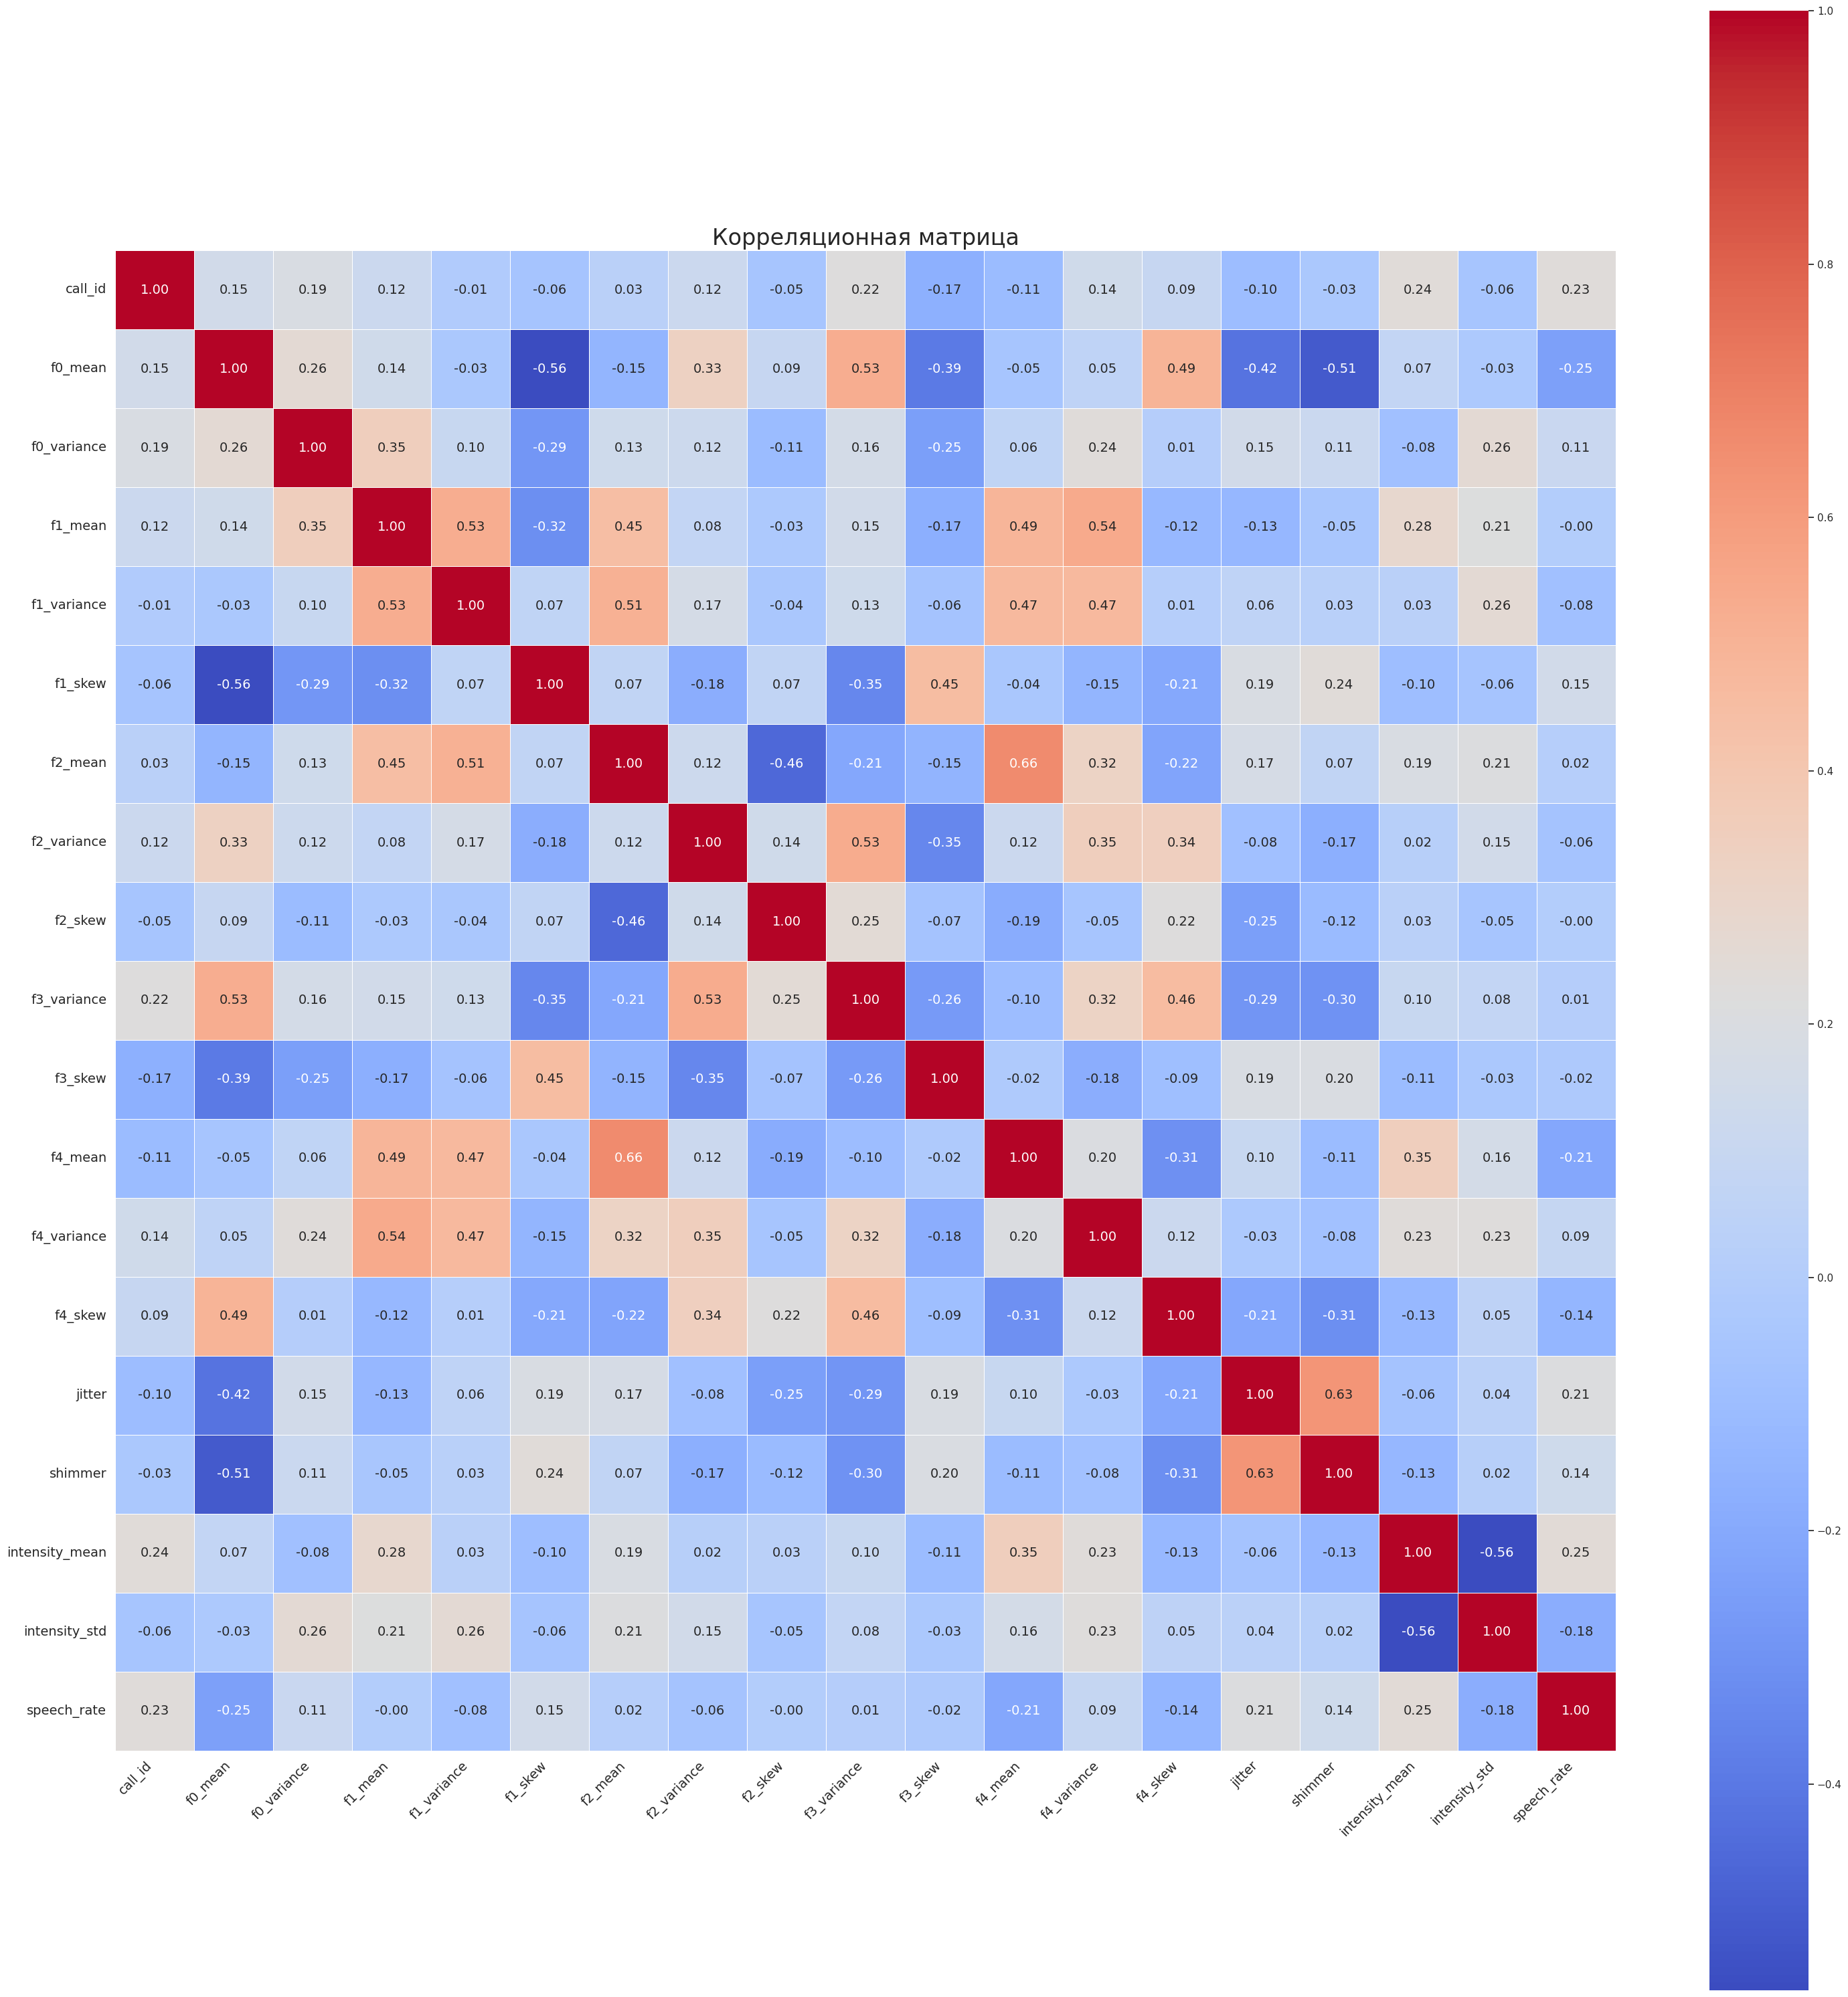

In [47]:
final_df = pd.read_csv("/home/user/papkamusik/action_folder/result_177.csv")
# Удаляем строки, где gender = "-"
final_df = final_df[final_df["sex"] != "-"].reset_index(drop=True)
# final_df = final_df[final_df["role"] != "assistant"].reset_index(drop=True)
final_df=final_df.dropna()
final_df.rename(columns={"sex": "gender"}, inplace=True)

# final_df.sex.unique()
final_df.info()

import matplotlib.pyplot as plt
import seaborn as sns

# -------- выбираем числовые признаки --------

final_df.drop(columns=["f0_cv","f1_cv","f2_cv","f3_cv","f4_cv","f0_median","f1_median","f2_median","f3_median","f4_median",
                       "f0_range","f1_range","f2_range","f3_range","f4_range","f0_std","f1_std","f2_std","f3_std","f4_std",
                       "f0_min","f0_max","f1_min","f1_max","f2_min","f2_max","f3_min","f3_max","f4_min","f4_max","f1_kurtosis",
                       "f2_kurtosis","f3_kurtosis","f4_kurtosis","f0_kurtosis","f3_mean","f0_skew"], inplace=True)
numeric = final_df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
# -------- корреляционная матрица --------
plt.figure(figsize=(30,30))  # увеличили размер

sns.set(font_scale=1)  # увеличили шрифт
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()


# убираем дубликаты и диагональ
upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# выбираем пары с корреляцией > 0.7
high_corr = [(col1, col2, upper.loc[col1, col2]) 
             for col1 in upper.columns 
             for col2 in upper.columns 
             if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] > 0.7]

# выводим
for col1, col2, val in high_corr:
    print(f"{col1} ↔ {col2}: {val:.2f}")

In [48]:
final_df

,call_id,role,f0_mean,f0_variance,f1_mean,f1_variance,f1_skew,f2_mean,f2_variance,f2_skew,...,f3_skew,f4_mean,f4_variance,f4_skew,jitter,shimmer,intensity_mean,intensity_std,speech_rate,gender
0,442,user,196.245302,2045.265824,411.873990,15849.676386,1.207032,1562.127538,96357.330467,0.026248,...,-0.269106,3097.839939,42706.383910,-0.150049,0.030808,0.094065,57.286904,14.442483,2.858776,female
1,892,user,222.431404,1587.431490,598.606390,27607.631002,0.633915,1408.689060,84530.246682,0.409671,...,-0.118379,3192.396147,55582.502335,0.233229,0.027930,0.100298,79.271496,9.201572,3.151178,female
2,1031,user,208.060655,1065.742325,389.499237,21964.766174,1.260541,1036.253780,184873.595797,1.229337,...,0.256953,3002.170403,63779.835357,0.605084,0.025376,0.102264,65.658334,11.535638,3.150535,female
3,1016,user,206.404335,1470.614332,581.943761,17873.859694,0.875252,1432.395201,191640.543050,0.300650,...,-0.425545,2988.583925,123672.697657,0.264688,0.020473,0.090412,68.981712,11.741398,3.025028,female
4,778,user,141.895040,1391.413956,543.263023,87570.832550,1.632572,1612.887209,140243.442919,0.399880,...,0.862612,3248.285949,145307.666185,1.429248,0.029785,0.089394,61.791128,17.161264,3.294118,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,1018,assistant,113.303421,700.096720,639.699931,65588.175219,0.897285,1643.495217,86863.367127,0.453151,...,-0.016225,3372.026600,56651.339309,-0.638885,0.022674,0.087363,81.422864,7.756495,3.257059,male
155,52,assistant,108.364596,468.362174,424.214857,7488.052956,1.846062,1340.360723,48308.899313,0.070162,...,0.585532,3038.505995,20734.542094,-1.157022,0.026754,0.107505,60.957301,9.861985,3.295012,male
156,668,assistant,200.853383,941.449018,533.509416,31462.450589,0.485166,1399.761764,115060.559509,0.693427,...,-0.552279,3015.829232,100497.570720,0.743614,0.021302,0.098976,69.231365,13.214776,3.061741,male
157,978,assistant,190.082862,1104.504144,427.127579,17254.506968,1.616227,1205.269508,107239.417651,0.462255,...,0.125688,2879.080623,44986.475696,0.861361,0.023206,0.091278,63.021539,11.000287,3.112147,female


In [ ]:


final_df = final_df[final_df["role"] == "user"]

auto_reduce_and_evaluate(
    final_df,
    group_column="gender",
    id_column="call_id"
)


📁 Output folder: /home/user/wav-parser/services/vizualization/plots

PCA components: 14
Explained variance: 0.951

================ FINAL RESULTS ================

✔ saved: plots/PCA_score_-0.323.html
✔ saved: plots/TSNE_p35_lr250.html
✔ saved: plots/UMAP_n15_md0.2.html
✔ saved: plots/PCA_TSNE_p35_lr250.html
✔ saved: plots/PCA_UMAP_n15_md0.2.html

TOP 10 CONFIGS:

    method     p     lr     score  silhouette         ch        db     n    md
127   UMAP   NaN    NaN -0.201040    0.189890  22.141823  1.483246  15.0  0.20
139   UMAP   NaN    NaN -0.203621    0.201252  22.403967  1.524595  20.0  0.50
77    TSNE  35.0  250.0 -0.208027    0.203034  21.893259  1.551001   NaN   NaN
136   UMAP   NaN    NaN -0.212549    0.182138  21.597682  1.521332  20.0  0.10
10    TSNE   8.0   10.0 -0.218288    0.206805  21.279939  1.611646   NaN   NaN
135   UMAP   NaN    NaN -0.221235    0.178128  20.642463  1.554594  20.0  0.08
133   UMAP   NaN    NaN -0.223518    0.182493  20.451607  1.576890  20.0  0.02


,method,p,lr,score,silhouette,ch,db,n,md
0,TSNE,5.0,10.0,-0.373073,0.131625,10.714207,2.196035,NaN,NaN
1,TSNE,5.0,25.0,-0.401644,0.132353,9.565560,2.340536,NaN,NaN
2,TSNE,5.0,50.0,-0.424562,0.113067,8.584100,2.406767,NaN,NaN
3,TSNE,5.0,75.0,-0.297979,0.171850,14.306111,1.921666,NaN,NaN
4,TSNE,5.0,100.0,-0.842806,0.060593,3.291521,4.366005,NaN,NaN
...,...,...,...,...,...,...,...,...,...
195,UMAP,NaN,NaN,-0.351866,0.105681,11.847699,2.025309,150.0,0.08
196,UMAP,NaN,NaN,-0.434462,0.082038,8.962604,2.378751,150.0,0.10
197,UMAP,NaN,NaN,-0.480608,0.055579,7.239595,2.543073,150.0,0.20
198,UMAP,NaN,NaN,-0.340291,0.116949,12.748171,1.995742,150.0,0.30


In [45]:
final_df

,role,f0_mean,f0_variance,f1_mean,f1_variance,f2_mean,f2_variance,f3_mean,f3_variance,jitter,shimmer,intensity_mean,intensity_std,speech_rate,gender
0,user,196.245302,2045.265824,411.873990,15849.676386,1562.127538,96357.330467,2338.419243,59473.843783,0.030808,0.094065,57.286904,14.442483,2.858776,female
1,user,222.431404,1587.431490,598.606390,27607.631002,1408.689060,84530.246682,2380.726633,80916.569304,0.027930,0.100298,79.271496,9.201572,3.151178,female
2,user,208.060655,1065.742325,389.499237,21964.766174,1036.253780,184873.595797,2191.834442,113599.105937,0.025376,0.102264,65.658334,11.535638,3.150535,female
3,user,206.404335,1470.614332,581.943761,17873.859694,1432.395201,191640.543050,2289.733887,87449.096536,0.020473,0.090412,68.981712,11.741398,3.025028,female
4,user,141.895040,1391.413956,543.263023,87570.832550,1612.887209,140243.442919,2466.415104,81420.575369,0.029785,0.089394,61.791128,17.161264,3.294118,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,user,239.507636,2082.188855,464.763081,37586.639956,1274.539114,129677.560653,2250.300426,31841.203734,0.029878,0.103756,55.706833,13.215712,2.363507,female
88,user,109.259401,1302.016883,452.349388,18664.624949,1340.904704,49648.600423,2218.088646,58238.879666,0.030362,0.123180,57.505290,12.558536,2.338532,female
89,user,191.488198,126.142453,413.146876,15567.687213,1224.782948,148287.592779,2125.788559,65649.135410,0.032928,0.121047,52.619698,10.225938,0.483325,female
90,user,167.884095,1042.677259,480.785802,28722.636457,1367.557440,243951.474476,2341.069219,178560.589728,0.029834,0.112742,71.141718,10.095679,4.512916,female


In [6]:

# final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated_clean.csv")

final_df = final_df.drop(columns=["f0_slope","f1_slope","f2_slope","f3_slope",
                                  "f1_range","f2_range","f3_range"])

numeric = final_df.select_dtypes(include=[np.number])

corr_matrix = numeric.corr()
# -------- корреляционная матрица --------
plt.figure(figsize=(30,30))  # увеличили размер

sns.set(font_scale=1)  # увеличили шрифт
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   call_id         70 non-null     int64  
 1   role            70 non-null     object 
 2   total_duration  70 non-null     float64
 3   f0_median       70 non-null     float64
 4   f0_std          70 non-null     float64
 5   f0_min          70 non-null     float64
 6   f0_max          70 non-null     float64
 7   f0_range        70 non-null     float64
 8   f1_median       70 non-null     float64
 9   f1_std          70 non-null     float64
 10  f1_min          70 non-null     float64
 11  f1_max          70 non-null     float64
 12  f1_range        70 non-null     float64
 13  f2_median       70 non-null     float64
 14  f2_std          70 non-null     float64
 15  f2_min          70 non-null     float64
 16  f2_max          70 non-null     float64
 17  f2_range        70 non-null     float

In [8]:
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import pandas as pd

final_df = pd.read_csv("/home/user/papkamusik/action_folder/google_folder/filtered_168.csv")
numeric = final_df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(numeric),
    columns=numeric.columns
)

X_scaled["sex"] = final_df["sex"].values
X_scaled["call_id"] = final_df["call_id"].values

fig = px.scatter(
    X_scaled,
    x="f0_median",
    y="f0_std",
    color="sex",   # колонка пола
    hover_data=["call_id"]
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ========================
# DATA
# ========================

df = final_df.copy()


# label_map = {"Male": 0, "Female": 1}
# inv_map = {0: "Male", 1: "Female"}

features = ["f0_median", "f0_variance"]

X = StandardScaler().fit_transform(df[features])

y_true = df["sex"].values
call_ids = df["call_id"].values

# ========================
# KNN
# ========================

k = 28

knn = NearestNeighbors(n_neighbors=k+1)
knn.fit(X)

distances, indices = knn.kneighbors(X)

# ========================
# PREDICT LOCAL LABEL
# ========================

pred_labels = []

for i in range(len(X)):
    neighbor_labels = y_true[indices[i][1:]]
    pred_label = pd.Series(neighbor_labels).mode()[0]
    pred_labels.append(pred_label)

pred_labels = np.array(pred_labels)

# ========================
# FIND WRONG LABELS
# ========================

mask_wrong = pred_labels != y_true

removed_ids = df.loc[mask_wrong, "call_id"]

# SAVE REMOVED
with open("removed_wrong_labels.txt", "w") as f:
    for x in removed_ids:
        f.write(str(x) + "\n")

# ========================
# DELETE FROM DATAFRAME
# ========================

df_clean = df.loc[~mask_wrong].copy()
# сохраняем
df_clean.to_csv("df_clean_final.csv", index=False)

print("Original:", len(df))
print("Removed :", mask_wrong.sum())
print("Cleaned :", len(df_clean))

# ========================
# VISUALIZE BEFORE
# ========================

tmp = pd.DataFrame(X, columns=features)
tmp["sex"] = y_true

fig = px.scatter(
    tmp,
    x="f0_median",
    y="f0_variance",
    color="sex",
    title="BEFORE CLEANING",
    hover_data=["call_id"]
)
fig.show()

# ========================
# VISUALIZE AFTER
# ========================

X2 = StandardScaler().fit_transform(df_clean[features])

tmp2 = pd.DataFrame(X2, columns=features)
tmp2["sex"] = df_clean["sex"].values

fig = px.scatter(
    tmp2,
    x="f0_median",
    y="f0_variance",
    color="sex",
    title="AFTER REMOVAL OF WRONG LABELS"
)
fig.show()


Original: 400
Removed : 94
Cleaned : 306


In [ ]:
# Data prep


In [11]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ============================================================
# 1. ЗАГРУЗКА И СЛИЯНИЕ ПО HASH
# ============================================================

features_df = pd.read_csv("/home/user/papkamusik/action_folder/features_1000.csv")
info_df = pd.read_csv("/home/user/papkamusik/action_folder/alone/hash_sex_age.csv")

# Объединяем по hash (внутреннее слияние — оставляем только те записи, где hash есть в обоих файлах)
df = pd.merge(features_df, info_df, on="hash", how="inner")

print(f"После слияния: {len(df)} строк")

# ============================================================
# 2. УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ (NaN) В ВАЖНЫХ КОЛОНКАХ
# ============================================================

required_cols = ["f0_median", "f0_variance", "sex", "hash"]
df = df.dropna(subset=required_cols).copy()

# Оставляем только корректные значения пола (Male/Female)
df = df[df["sex"].isin(["Male", "Female"])].copy()

print(f"После удаления NaN и невалидного пола: {len(df)} строк")

# ============================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ KNN
# ============================================================

features = ["f0_median", "f0_variance"]
X = StandardScaler().fit_transform(df[features])
y_true = df["sex"].values
hash_ids = df["hash"].values

# ============================================================
# 4. KNN (k=28)
# ============================================================
k = 28

if len(df) < k + 1:
    raise ValueError(f"Выборка слишком мала: {len(df)} строк, нужно хотя бы {k+1}")

knn = NearestNeighbors(n_neighbors=k+1)
knn.fit(X)
distances, indices = knn.kneighbors(X)

# Предсказываем метку для каждой точки голосованием её k соседей
pred_labels = []
for i in range(len(X)):
    neighbor_labels = y_true[indices[i][1:]]   # исключаем саму точку
    pred_label = pd.Series(neighbor_labels).mode()[0]
    pred_labels.append(pred_label)
pred_labels = np.array(pred_labels)

# ============================================================
# 5. ВЫЯВЛЕНИЕ ОШИБОЧНО РАЗМЕЧЕННЫХ (KNN не совпадает с истинным полом)
# ============================================================
mask_wrong = pred_labels != y_true

# Информация об удаляемых точках (для топ-100)
removed_info = []
for i in np.where(mask_wrong)[0]:
    removed_info.append({
        "hash": hash_ids[i],
        "true_sex": y_true[i],
        "pred_sex": pred_labels[i],
        "dist_to_kth_neighbor": distances[i, -1]   # расстояние до самого дальнего соседа
    })
removed_df = pd.DataFrame(removed_info)

# ============================================================
# 6. ТОП-100 УДАЛЁННЫХ (по убыванию расстояния)
# ============================================================
if len(removed_df) > 0:
    top100 = removed_df.sort_values("dist_to_kth_neighbor", ascending=False).head(100)
    print("\n=== TOP 100 REMOVED (sorted by distance to k-th neighbor) ===")
    print(top100[["hash", "true_sex", "pred_sex", "dist_to_kth_neighbor"]])
    top100.to_csv("top100_removed.csv", index=False)
else:
    print("Нет удаляемых записей.")

# Сохраняем полный список удалённых hash в текстовый файл
removed_hashes = df.loc[mask_wrong, "hash"]
with open("removed_wrong_labels.txt", "w") as f:
    for h in removed_hashes:
        f.write(str(h) + "\n")

# ============================================================
# 7. УДАЛЯЕМ НЕПРАВИЛЬНЫЕ ЗАПИСИ И СОХРАНЯЕМ ОЧИЩЕННЫЙ ДАТАФРЕЙМ
# ============================================================
df_clean = df.loc[~mask_wrong].copy()

print(f"\nOriginal: {len(df)}")
print(f"Removed : {mask_wrong.sum()}")
print(f"Cleaned : {len(df_clean)}")

# ============================================================
# 8. ВИЗУАЛИЗАЦИЯ ДО ОЧИСТКИ
# ============================================================
tmp = pd.DataFrame(X, columns=features)
tmp["sex"] = y_true

fig1 = px.scatter(
    tmp,
    x="f0_median",
    y="f0_variance",
    color="sex",
    title="BEFORE CLEANING",
    hover_data={"hash": hash_ids}
)
fig1.show()

# ============================================================
# 9. ВИЗУАЛИЗАЦИЯ ПОСЛЕ ОЧИСТКИ
# ============================================================
if len(df_clean) > 0:
    X2 = StandardScaler().fit_transform(df_clean[features])
    tmp2 = pd.DataFrame(X2, columns=features)
    tmp2["sex"] = df_clean["sex"].values
    fig2 = px.scatter(
        tmp2,
        x="f0_median",
        y="f0_variance",
        color="sex",
        title="AFTER REMOVAL OF WRONG LABELS"
    )
    fig2.show()
else:
    print("После очистки нет данных для визуализации.")

После слияния: 1538 строк
После удаления NaN и невалидного пола: 1452 строк

=== TOP 100 REMOVED (sorted by distance to k-th neighbor) ===
                                 hash true_sex pred_sex  dist_to_kth_neighbor
145  3da7a38b4316845cce22c0ff6953526c     Male   Female              3.007686
492  ad7b5e4b8dbf43b5b997aa732574108f     Male   Female              2.360347
183  bed338c3826a0f40bd6ec1c3a91503a1     Male   Female              2.297100
457  5970ab5d9a49add798167c7a3fecf54e   Female     Male              2.175446
242  36e8fff11e4cc01a1fc058cc69871118     Male   Female              1.909538
..                                ...      ...      ...                   ...
548  54d56e0b28d9cb43dfe5ec2d6534644e     Male   Female              0.395198
416  a059d8aa284e97d86c874c27f046d907   Female     Male              0.393154
394  b65f0fc35f0107afc2425d1c7a87c8fc   Female     Male              0.391215
5    fa17a0da3b60ca69f2cfad412ade0ee8     Male   Female              0.391028
175